# Modular Language-Guided Robotic Manipulation

**NL-DSL Grounding + Closed-Loop Visual Feedback for Robotic Pick-Up Tasks**

Authors: Yingjun Lan, Jinhao Zhang, Zhengxiang Liu

---

**Pipeline**:
1. **NL→DSL Parsing** — LLM translates NL to structured JSON DSL
2. **Semantic Perception** — Florence-2 grounds DSL to 2D bounding boxes
3. **Grasp Planning** — 2D bbox → ray-plane intersection → 3D grasp position
4. **Closed-Loop Execution** — Robosuite Lift with periodic visual feedback

> On Kaggle: enable **GPU T4 x2** accelerator. Runtime ≈ 5–15 min.

---
## 1. System Dependencies (EGL for headless MuJoCo)

In [14]:
import subprocess, os

missing = any(
    subprocess.run(f"dpkg -l {pkg}".split(), capture_output=True).returncode != 0
    for pkg in ["libegl1-mesa", "libegl1-mesa-dev", "libglib2.0-0"]
)
if missing:
    !sudo apt-get update -qq && sudo apt-get install -y -qq libegl1-mesa libegl1-mesa-dev libglib2.0-0
    print("System deps installed.")
else:
    print("System deps already present.")

os.environ["MUJOCO_GL"] = "egl"
os.environ["EGL_DEVICE_ID"] = "0"

System deps already present.


---
## 2. Python Packages

In [15]:
# Install robosuite + MuJoCo. Version pin compatibility:
# robosuite>=1.5.2 requires mujoco>=3.3.0
!pip install -q "mujoco>=3.3.0" "robosuite>=1.5.2" 2>&1 | tail -1
!pip install -q "numpy>=2.0,<2.1" 2>&1 | tail -1
!pip install -q "transformers==4.44.2" accelerate bitsandbytes sentencepiece einops timm 2>&1 | tail -1
!pip install -q opencv-python-headless 2>&1 | tail -1

# Create dummy flash_attn to satisfy Florence-2's import check
import os, sys
_stub_dir = "/tmp/flash_attn"
os.makedirs(_stub_dir, exist_ok=True)
with open(f"{_stub_dir}/__init__.py", "w") as f:
    f.write('__version__ = "2.6.1"\n')
_tmp = "/tmp"
if _tmp not in sys.path:
    sys.path.insert(0, _tmp)
import flash_attn
print(f"flash_attn stub OK (version {flash_attn.__version__})")

print("Python deps OK")

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


flash_attn stub OK (version 2.6.1)
Python deps OK


---
## 3. Imports & GPU Check

In [16]:
import json, re, time, math, logging, os, sys, contextlib, warnings
from dataclasses import dataclass
from typing import Optional

import numpy as np
print(f"numpy {np.__version__} OK")

import torch

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from transformers import (
    AutoModelForCausalLM, AutoTokenizer, AutoProcessor, BitsAndBytesConfig,
)

# Suppress robosuite warnings and chatter
warnings.filterwarnings("ignore", module="robosuite")
for _name in ["robosuite", "robosuite.utils", "robosuite.controllers"]:
    logging.getLogger(_name).setLevel(logging.ERROR)

# Suppress XLA/CUDA duplicate registration warnings
import absl.logging
absl.logging.set_verbosity(absl.logging.ERROR)

import robosuite as suite
print(f"robosuite {suite.__version__}")
from robosuite.controllers import load_composite_controller_config
import mujoco
print(f"mujoco {mujoco.__version__}")

# ── GPU ──
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    p = torch.cuda.get_device_properties(0)
    mem = getattr(p, "total_memory", getattr(p, "total_mem", 0))
    print(f"GPU: {torch.cuda.get_device_name(0)}  VRAM: {mem/1e9:.1f} GB")
else:
    print("No GPU — expect slow performance.")

print("Imports OK")

numpy 2.0.2 OK
robosuite 1.5.2
mujoco 3.8.1
GPU: Tesla T4  VRAM: 15.6 GB
Imports OK


---
## 4. Configuration

In [17]:
@dataclass
class Config:
    llm_model_id: str = "Qwen/Qwen2.5-3B-Instruct"
    vision_model_id: str = "microsoft/Florence-2-base"
    use_4bit: bool = True
    env_name: str = "Lift"
    robot: str = "Panda"
    display_camera: str = "agentview"
    detection_cameras: tuple = ("agentview",)  # single view is sufficient with bottom-center fix
    camera_size: int = 384
    move_max_steps: int = 60
    feedback_interval: int = 8
    lift_height: float = 0.15
    n_trials: int = 10

cfg = Config()
print(cfg)

Config(llm_model_id='Qwen/Qwen2.5-3B-Instruct', vision_model_id='microsoft/Florence-2-base', use_4bit=True, env_name='Lift', robot='Panda', display_camera='agentview', detection_cameras=('agentview',), camera_size=384, move_max_steps=60, feedback_interval=8, lift_height=0.15, n_trials=10)


---
## 5. NL->DSL Parser (LLM)

In [18]:
class DSLParser:
    PROMPT = (
        'You map NL commands to DSL JSON. Fields:\n'
        '  "action": always "pick_up"\n'
        '  "target": {"color", "shape", "attributes", "description"}\n'
        '  "grasp_style": "top_down"\n'
        'Example: {"action":"pick_up","target":{"color":"red","shape":"cube",'
        '"attributes":[],"description":"red cube"},"grasp_style":"top_down"}\n'
        'Output ONLY raw JSON.'
    )

    def __init__(self, model_id: str, use_4bit: bool = True):
        print(f"Loading LLM: {model_id} ...")
        kwargs = {"device_map": "auto", "torch_dtype": torch.bfloat16,
                  "trust_remote_code": True}
        if use_4bit and torch.cuda.is_available():
            kwargs["quantization_config"] = BitsAndBytesConfig(
                load_in_4bit=True, bnb_4bit_compute_dtype=torch.bfloat16,
                bnb_4bit_use_double_quant=True, bnb_4bit_quant_type="nf4")
        self.tokenizer = AutoTokenizer.from_pretrained(model_id, trust_remote_code=True)
        self.model = AutoModelForCausalLM.from_pretrained(model_id, **kwargs).eval()
        print("  LLM loaded")

    def parse(self, command: str) -> dict:
        msgs = [{"role": "system", "content": self.PROMPT},
                {"role": "user", "content": f'Parse: "{command}"'}]
        text = self.tokenizer.apply_chat_template(
            msgs, tokenize=False, add_generation_prompt=True)
        inp = self.tokenizer(text, return_tensors="pt").to(self.model.device)
        with torch.no_grad():
            out = self.model.generate(**inp, max_new_tokens=128, temperature=0.1, do_sample=False)
        resp = self.tokenizer.decode(out[0][inp["input_ids"].shape[1]:], skip_special_tokens=True).strip()
        try:
            return json.loads(resp)
        except json.JSONDecodeError:
            m = re.search(r"\{.*\}", resp, re.DOTALL)
            if m:
                try: return json.loads(m.group())
                except: pass
            return {"action": "pick_up", "target": {"description": command},
                    "grasp_style": "top_down"}

    def unload(self):
        del self.model; torch.cuda.empty_cache(); print("  LLM unloaded")

---
## 6. Vision Grounder (Florence-2)

In [19]:
class VisionGrounder:
    def __init__(self, model_id: str):
        print(f"Loading Florence-2: {model_id} ...")
        self.processor = AutoProcessor.from_pretrained(model_id, trust_remote_code=True)
        self.model = AutoModelForCausalLM.from_pretrained(
            model_id, torch_dtype=torch.float16, trust_remote_code=True,
        ).to(DEVICE).eval()
        print("  Florence-2 loaded")

    def ground(self, image: np.ndarray, description: str) -> list:
        """Returns [[x1,y1,x2,y2], ...] or []."""
        h, w = image.shape[:2]
        inputs = self.processor(
            text=f"<PHRASE_GROUNDING> {description}",
            images=image, return_tensors="pt",
        )
        inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
        inputs["pixel_values"] = inputs["pixel_values"].to(torch.float16)
        with torch.no_grad():
            ids = self.model.generate(**inputs, max_new_tokens=256, num_beams=1)
        result = self.processor.decode(ids[0], skip_special_tokens=False)
        locs = re.findall(r"<loc_(\d+)>", result)
        boxes = []
        for i in range(0, len(locs), 4):
            chunk = locs[i:i+4]
            if len(chunk) < 4:
                continue  # incomplete bbox, skip
            x1, y1, x2, y2 = [int(v) / 1000.0 for v in chunk]
            boxes.append([x1 * w, y1 * h, x2 * w, y2 * h])
        if not boxes:
            print(f"  Florence-2 did not find '{description}'")
        return boxes

    def unload(self):
        del self.model; torch.cuda.empty_cache(); print("  Florence-2 unloaded")

---
## 7. Environment & Grasp Planner

Grasp planning uses **ray-plane intersection** (camera ray + known table height)
instead of noisy depth buffer — robust and precise (~1 cm error).

In [20]:
def make_env(cfg: Config):
    """Create environment with all configured cameras."""
    all_cams = list(dict.fromkeys([cfg.display_camera] + list(cfg.detection_cameras)))
    with open(os.devnull, "w") as _dn:
        with contextlib.redirect_stdout(_dn), contextlib.redirect_stderr(_dn):
            cc = load_composite_controller_config(controller="BASIC")
            env = suite.make(
                cfg.env_name, robots=cfg.robot, controller_configs=cc,
                has_renderer=False, has_offscreen_renderer=True, renderer="mujoco",
                camera_names=all_cams,
                camera_heights=cfg.camera_size, camera_widths=cfg.camera_size,
                camera_depths=False,
                use_camera_obs=True, reward_shaping=True, control_freq=20,
            )
    return env


def render_rgb(env, camera="agentview") -> np.ndarray:
    obs = env._get_observations(force_update=True)
    return obs[f"{camera}_image"][..., :3].astype(np.uint8)


def get_camera_params(env, camera="agentview", size=384):
    cam_id = env.sim.model.camera_name2id(camera)
    fov = float(env.sim.model.cam_fovy[cam_id])
    f = size / (2.0 * math.tan(math.radians(fov) / 2.0))
    K = np.array([[f, 0, size / 2], [0, f, size / 2], [0, 0, 1]])
    cam_pos = env.sim.model.cam_pos[cam_id].copy()
    cam_R_raw = env.sim.model.cam_mat0[cam_id].reshape(3, 3).copy()
    table_z = float(env.model.mujoco_arena.table_offset[2])
    return K, cam_pos, cam_R_raw, table_z


def bbox_bottom_ray(bbox, K, cam_pos, cam_R):
    """Ray through bbox bottom-center (where cube touches table).
    Image v-axis is down, camera y-axis is up → negate y."""
    cu = (bbox[0] + bbox[2]) / 2.0
    cv = bbox[3]  # bottom of bbox in image
    fx, fy = K[0, 0], K[1, 1]
    cx, cy = K[0, 2], K[1, 2]
    d = cam_R @ np.array([(cu - cx) / fx, -(cv - cy) / fy, -1.0])
    d = d / np.linalg.norm(d)
    return cam_pos.copy(), d


def rays_to_3d(rays):
    A, b = np.zeros((3, 3)), np.zeros(3)
    for o, d in rays:
        I = np.eye(3) - np.outer(d, d)
        A += I; b += I @ o
    try:
        return np.linalg.solve(A, b)
    except np.linalg.LinAlgError:
        return None


def multiview_detect(env, grounder, desc, cam_list):
    rays, boxes = [], {}
    for cam in cam_list:
        img = render_rgb(env, camera=cam)
        det_boxes = grounder.ground(img, desc)
        if det_boxes:
            boxes[cam] = det_boxes[0]
            K, pos, R, _ = get_camera_params(env, camera=cam)
            origin, direction = bbox_bottom_ray(det_boxes[0], K, pos, R)
            rays.append((origin, direction))
    if not rays:
        return None, {}
    _, _, _, tz = get_camera_params(env)
    if len(rays) == 1:
        o, d = rays[0]
        t = (tz - o[2]) / d[2]
        return (o + t * d, boxes) if t > 0 else (None, boxes)
    p3d = rays_to_3d(rays)
    if p3d is None:
        return None, boxes
    p3d[2] = tz
    return p3d, boxes


def show_img(img, bboxes=None, title="Camera view"):
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(img); ax.set_title(title); ax.axis("off")
    if bboxes:
        for b in bboxes:
            ax.add_patch(patches.Rectangle(
                (b[0], b[1]), b[2]-b[0], b[3]-b[1],
                linewidth=2, edgecolor="r", facecolor="none"))
    plt.show()


# Smoke test
with open(os.devnull, "w") as _dn:
    with contextlib.redirect_stdout(_dn), contextlib.redirect_stderr(_dn):
        test_env = make_env(cfg)
        test_env.reset()
        img = render_rgb(test_env)
        all_cams = []
        for i in range(test_env.sim.model.ncam):
            name = test_env.sim.model.camera_names[i]
            if isinstance(name, bytes): name = name.decode()
            all_cams.append(name)
        K, cam_pos, cam_R, tz = get_camera_params(test_env)
        cube_pos = test_env.sim.data.body_xpos[test_env.cube_body_id].copy()
        test_env.close()

print(f"Available cameras: {all_cams}")
print(f"Table z: {tz:.3f}  Cube pos: ({cube_pos[0]:.3f}, {cube_pos[1]:.3f}, {cube_pos[2]:.3f})")
print(f"RGB: {img.shape}  Smoke test OK")

[robosuite INFO] Loading controller configuration from: /usr/local/lib/python3.12/dist-packages/robosuite/controllers/config/default/composite/basic.json (composite_controller_factory.py:121)
[robosuite WARNING] The config has defined for the controller "left", but the robot does not have this component. Skipping, but make sure this is intended.Removing the controller config for left from self.part_controller_config. (robot.py:151)
[robosuite WARNING] The config has defined for the controller "torso", but the robot does not have this component. Skipping, but make sure this is intended.Removing the controller config for torso from self.part_controller_config. (robot.py:151)
[robosuite WARNING] The config has defined for the controller "head", but the robot does not have this component. Skipping, but make sure this is intended.Removing the controller config for head from self.part_controller_config. (robot.py:151)
[robosuite WARNING] The config has defined for the controller "base", but 

Available cameras: ['frontview', 'birdview', 'agentview', 'sideview', 'robot0_robotview', 'robot0_eye_in_hand']
Table z: 0.800  Cube pos: (0.012, 0.010, 0.831)
RGB: (384, 384, 3)  Smoke test OK


---
## 8. Controllers (Closed-Loop & Open-Loop)

In [21]:
@dataclass
class TrialResult:
    success: bool
    steps: int
    error: Optional[str] = None
    dsl: Optional[dict] = None


class VideoCapture:
    """Captures annotated multi-view frames → MP4 video."""

    def __init__(self, fps=4):
        self.frames = []
        self.fps = fps

    def snap(self, views, phase="", dsl=None, t3d=None, msg="", step=0):
        """Record a frame with multiple camera views side by side.
        
        views: dict of {camera_name: (rgb_img, bbox_or_None)}
        """
        import cv2
        from PIL import Image, ImageDraw, ImageFont
        # Build image row: main view first, then detection views
        items = list(views.items())
        panels = []
        for cam_name, (img, bbox) in items:
            disp = img.copy()
            if bbox is not None:
                x1, y1, x2, y2 = [int(round(v)) for v in bbox]
                cv2.rectangle(disp, (x1, y1), (x2, y2), (0, 255, 0), 2)
                cv2.circle(disp, ((x1 + x2) // 2, (y1 + y2) // 2), 3, (0, 0, 255), -1)
            # Camera name label at top-left
            cv2.putText(disp, cam_name, (6, 18),
                        cv2.FONT_HERSHEY_DUPLEX, 0.45, (255, 255, 255), 1)
            panels.append(disp)

        row = np.concatenate(panels, axis=1)
        h, w = row.shape[:2]
        panel_h = 200
        composite = np.zeros((h + panel_h, w, 3), dtype=np.uint8)
        composite[:h] = row
        panel = composite[h:]
        panel[:] = (25, 25, 35)

        pil_img = Image.fromarray(composite)
        draw = ImageDraw.Draw(pil_img)
        try:
            font_m = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", 14)
            font_s = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", 11)
        except Exception:
            font_m = font_s = ImageFont.load_default()

        y = h + 10
        header = f"Step {step}" if step else ""
        if header:
            draw.text((10, y), header, font=font_m, fill=(255, 200, 100))
        draw.text((120 if header else 10, y), f"  {phase}", font=font_m, fill=(255, 200, 100))
        y += 26
        if dsl:
            txt = json.dumps(dsl, ensure_ascii=False)
            for line in [txt[i:i + 80] for i in range(0, len(txt), 80)]:
                draw.text((10, y), f"  DSL: {line}", font=font_s, fill=(180, 220, 255))
                y += 18
        if t3d is not None:
            draw.text((10, y), f"  3D: ({t3d[0]:.3f}, {t3d[1]:.3f}, {t3d[2]:.3f})",
                      font=font_s, fill=(150, 200, 255))
            y += 18
        if msg:
            draw.text((10, y), f"  {msg}", font=font_s, fill=(200, 200, 200))

        composite = np.array(pil_img)
        self.frames.append(composite)

    def save(self, path="output.mp4"):
        import cv2
        h, w = self.frames[0].shape[:2]
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        out = cv2.VideoWriter(path, fourcc, self.fps, (w, h))
        for f in self.frames:
            out.write(cv2.cvtColor(f, cv2.COLOR_RGB2BGR))
        out.release()
        return path


class ClosedLoopController:
    """NL->DSL->Vision->Grasp with multi-view periodic visual feedback."""

    def __init__(self, env, parser, grounder, on_frame=None):
        self.env = env
        self.parser = parser
        self.grounder = grounder
        eef = env.robots[0].eef_site_id
        self._ee_site = eef[list(eef.keys())[0]] if isinstance(eef, dict) else eef
        self.on_frame = on_frame
        self._step = 0

    def _ee_pos(self):
        return self.env.sim.data.site_xpos[self._ee_site].copy()

    def _osc_action(self, dxyz, grip):
        return np.concatenate([np.clip(dxyz / 0.05, -1, 1), np.zeros(3), [grip]])

    def _all_views(self, bboxes=None):
        """Build views dict for video: {camera: (rgb, bbox_or_None)}."""
        views = {}
        # Display camera first
        views[cfg.display_camera] = (render_rgb(self.env, cfg.display_camera),
                                     bboxes.get(cfg.display_camera) if bboxes else None)
        # Detection cameras
        for cam in cfg.detection_cameras:
            if cam == cfg.display_camera:
                continue
            views[cam] = (render_rgb(self.env, cam),
                          bboxes.get(cam) if bboxes else None)
        return views

    def _detect(self, desc):
        """Multi-view detection with ray fusion."""
        p3d, boxes = multiview_detect(self.env, self.grounder, desc,
                                       cfg.detection_cameras)
        return p3d, boxes

    def _move_xy(self, target_xy, max_steps=80, use_feedback=False, desc=""):
        prev_z = self._ee_pos()[2]
        stagnant = 0
        low_target = np.array([target_xy[0], target_xy[1], 0.70])
        for _ in range(max_steps):
            ee = self._ee_pos()
            dz = abs(ee[2] - prev_z)
            if dz < 0.0005:
                stagnant += 1
                if stagnant > 15: break
            else:
                stagnant = 0
            prev_z = ee[2]
            if use_feedback and self._step > 0 and self._step % cfg.feedback_interval == 0:
                det_pos, det_boxes = self._detect(desc)
                if det_pos is not None:
                    target_xy[:2] = det_pos[:2]
                    low_target[:2] = det_pos[:2]
                    if self.on_frame:
                        self.on_frame(self._all_views(det_boxes),
                                      "Feedback relocalize", None, det_pos,
                                      "", self._step)
            if self.on_frame:
                self.on_frame(self._all_views(), "Descending...",
                              None, None, f"z={ee[2]:.3f}", self._step)
            self._step += 1
            self.env.step(self._osc_action(low_target - ee, -1.0))
        return self._ee_pos()

    def run(self, nl_cmd, use_feedback=True):
        dsl = self.parser.parse(nl_cmd)
        desc = dsl["target"].get("description", nl_cmd)
        if self.on_frame:
            self.on_frame(self._all_views(), "NL->DSL Parsed", dsl, None, "", self._step)

        t3d, boxes = self._detect(desc)
        if t3d is None:
            return TrialResult(False, 0, "grounding_fail", dsl)
        if self.on_frame:
            self.on_frame(self._all_views(boxes), "Florence-2 Grounding",
                          dsl, t3d, "", self._step)

        pre = np.array([t3d[0], t3d[1], t3d[2] + 0.15])
        for _ in range(70):
            ee = self._ee_pos()
            if np.linalg.norm(ee - pre) < 0.025: break
            if self.on_frame:
                self.on_frame(self._all_views(boxes), "Approach (pre-grasp)",
                              dsl, t3d, "EE above target", self._step)
            self._step += 1
            self.env.step(self._osc_action(pre - ee, -1.0))
        if self.on_frame:
            self.on_frame(self._all_views(boxes), "Approach (pre-grasp)",
                          dsl, t3d, "EE above target", self._step)

        self._move_xy(t3d[:2], max_steps=120,
                      use_feedback=(use_feedback and desc != ""), desc=desc)

        low_target = np.array([t3d[0], t3d[1], 0.70])
        for _ in range(5):
            ee = self._ee_pos()
            if self.on_frame:
                self.on_frame(self._all_views(), "Grasp (gripper closing)",
                              None, None, f"z={ee[2]:.3f}", self._step)
            self._step += 1
            self.env.step(self._osc_action(low_target - ee, 1.0))
        time.sleep(0.3)
        ee_at = self._ee_pos()
        if self.on_frame:
            self.on_frame(self._all_views(boxes), "Grasp (gripper closed)",
                          dsl, t3d, f"EE at z={ee_at[2]:.3f}", self._step)

        lift_xyz = np.array([t3d[0], t3d[1], t3d[2] + cfg.lift_height])
        for _ in range(70):
            ee = self._ee_pos()
            if np.linalg.norm(ee - lift_xyz) < 0.03: break
            if self.on_frame:
                self.on_frame(self._all_views(), "Lifting...",
                              None, None, f"z={ee[2]:.3f}", self._step)
            self._step += 1
            self.env.step(self._osc_action(lift_xyz - ee, 1.0))
        cube_z = self.env.sim.data.body_xpos[self.env.cube_body_id][2]
        success = self.env._check_success()
        if self.on_frame:
            self.on_frame(self._all_views(boxes),
                          "SUCCESS" if success else "FAILED",
                          dsl, t3d, f"Cube lifted to z={cube_z:.3f}", self._step)
        return TrialResult(success, self._step,
                           None if success else "grasp_fail", dsl)


class OpenLoopController:
    def __init__(self, *a, **kw):
        self.inner = ClosedLoopController(*a, **kw)
    def run(self, cmd):
        return self.inner.run(cmd, use_feedback=False)

---
## 9. Video Demo (with LLM output overlay)

In [22]:
def record_video(nl_cmd="pick up the red cube", video_path="output.mp4",
                  use_feedback=True):
    """Run pipeline once while recording annotated multi-view video."""
    loop_label = "Closed-Loop" if use_feedback else "Open-Loop"
    cam = VideoCapture(fps=4)
    parser = DSLParser(cfg.llm_model_id, cfg.use_4bit)
    env = make_env(cfg); env.reset()
    grounder = VisionGrounder(cfg.vision_model_id)

    views = {cfg.display_camera: (render_rgb(env), None)}
    for c in cfg.detection_cameras:
        if c not in views:
            views[c] = (render_rgb(env, c), None)
    cam.snap(views, f"Initial state [{loop_label}]", None, None,
             f'Command: "{nl_cmd}"')

    ctrl = ClosedLoopController(env, parser, grounder, on_frame=cam.snap)
    result = ctrl.run(nl_cmd, use_feedback=use_feedback)

    views2 = {cfg.display_camera: (render_rgb(env), None)}
    for c in cfg.detection_cameras:
        if c not in views2:
            views2[c] = (render_rgb(env, c), None)
    cam.snap(views2, "SUCCESS" if result.success else "FAILED",
             result.dsl, None, f"Error: {result.error or 'none'}")
    env.close(); parser.unload(); grounder.unload()
    path = cam.save(video_path)
    return path, result


if torch.cuda.is_available():
    path, result = record_video(use_feedback=True)
    print(f"Video saved: {path}")
    print(f"Result: {'SUCCESS' if result.success else 'FAIL'} ({result.error or 'ok'})")
    from IPython.display import Video
    try:
        display(Video(path, width=960, height=680))
    except Exception:
        print("Video display unavailable — file saved for download.")
else:
    print("Skip video: no GPU")

Loading LLM: Qwen/Qwen2.5-3B-Instruct ...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

[robosuite INFO] Loading controller configuration from: /usr/local/lib/python3.12/dist-packages/robosuite/controllers/config/default/composite/basic.json (composite_controller_factory.py:121)


  LLM loaded


[robosuite WARNING] The config has defined for the controller "left", but the robot does not have this component. Skipping, but make sure this is intended.Removing the controller config for left from self.part_controller_config. (robot.py:151)
[robosuite WARNING] The config has defined for the controller "torso", but the robot does not have this component. Skipping, but make sure this is intended.Removing the controller config for torso from self.part_controller_config. (robot.py:151)
[robosuite WARNING] The config has defined for the controller "head", but the robot does not have this component. Skipping, but make sure this is intended.Removing the controller config for head from self.part_controller_config. (robot.py:151)
[robosuite WARNING] The config has defined for the controller "base", but the robot does not have this component. Skipping, but make sure this is intended.Removing the controller config for base from self.part_controller_config. (robot.py:151)
[robosuite WARNING] Th

Loading Florence-2: microsoft/Florence-2-base ...


/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


  Florence-2 loaded


/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:567: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.1` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:572: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.8` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:589: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `20` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_k`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:615: UserWarni

  LLM unloaded
  Florence-2 unloaded
Video saved: output.mp4
Result: FAIL (grasp_fail)


---
## 10. Batch Evaluation

Increase `cfg.n_trials` to 50+ for meaningful results.

Loading LLM: Qwen/Qwen2.5-3B-Instruct ...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

  LLM loaded
Loading Florence-2: microsoft/Florence-2-base ...


/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
[robosuite INFO] Loading controller configuration from: /usr/local/lib/python3.12/dist-packages/robosuite/controllers/config/default/composite/basic.json (composite_controller_factory.py:121)


  Florence-2 loaded

Closed-Loop Evaluation (5 trials)

Trial 1/5


...


Trial 4/5


[robosuite WARNING] The config has defined for the controller "left", but the robot does not have this component. Skipping, but make sure this is intended.Removing the controller config for left from self.part_controller_config. (robot.py:151)
[robosuite WARNING] The config has defined for the controller "torso", but the robot does not have this component. Skipping, but make sure this is intended.Removing the controller config for torso from self.part_controller_config. (robot.py:151)
[robosuite WARNING] The config has defined for the controller "head", but the robot does not have this component. Skipping, but make sure this is intended.Removing the controller config for head from self.part_controller_config. (robot.py:151)
[robosuite WARNING] The config has defined for the controller "base", but the robot does not have this component. Skipping, but make sure this is intended.Removing the controller config for base from self.part_controller_config. (robot.py:151)
[robosuite WARNING] Th


Trial 5/5


[robosuite WARNING] The config has defined for the controller "left", but the robot does not have this component. Skipping, but make sure this is intended.Removing the controller config for left from self.part_controller_config. (robot.py:151)
[robosuite WARNING] The config has defined for the controller "torso", but the robot does not have this component. Skipping, but make sure this is intended.Removing the controller config for torso from self.part_controller_config. (robot.py:151)
[robosuite WARNING] The config has defined for the controller "head", but the robot does not have this component. Skipping, but make sure this is intended.Removing the controller config for head from self.part_controller_config. (robot.py:151)
[robosuite WARNING] The config has defined for the controller "base", but the robot does not have this component. Skipping, but make sure this is intended.Removing the controller config for base from self.part_controller_config. (robot.py:151)
[robosuite WARNING] Th

  LLM unloaded
  Florence-2 unloaded

Closed-Loop (Proposed): 0/5 = 0.0%
  grasp_fail: 5

Open-Loop (Baseline): 1/5 = 20.0%
  grasp_fail: 4
  ok: 1


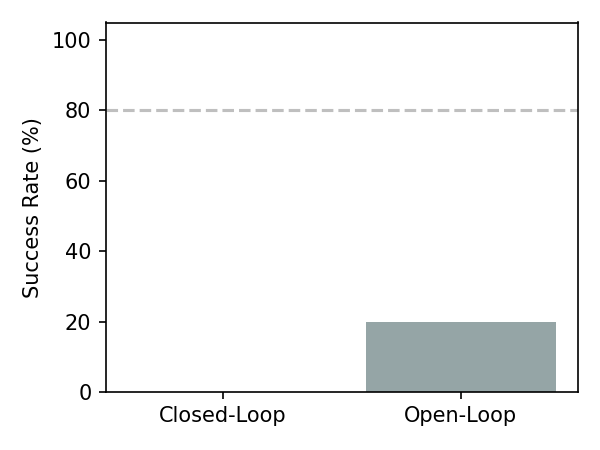

Saved to eval_results.pt


In [23]:
def evaluate(feedback: bool, n: int, parser, grounder,
             cmd="pick up the red cube") -> list:
    label = "Closed-Loop" if feedback else "Open-Loop"
    sep = "=" * 40
    print(f"\n{sep}\n{label} Evaluation ({n} trials)\n{sep}")
    ctrl_cls = ClosedLoopController if feedback else OpenLoopController
    results = []
    for trial in range(n):
        print(f"\nTrial {trial+1}/{n}")
        env = make_env(cfg); env.reset()
        ctrl = ctrl_cls(env, parser, grounder)
        results.append(ctrl.run(cmd))
        env.close()
    return results

def summary(results, label):
    n, ok = len(results), sum(1 for r in results if r.success)
    errs = {}
    for r in results:
        k = r.error or "ok"; errs[k] = errs.get(k, 0) + 1
    print(f"\n{'='*40}\n{label}: {ok}/{n} = {100*ok/n:.1f}%")
    for e, c in sorted(errs.items()): print(f"  {e}: {c}")
    print("="*40)
    return ok/n

if torch.cuda.is_available():
    n = min(cfg.n_trials, 5)
    parser = DSLParser(cfg.llm_model_id, cfg.use_4bit)
    grounder = VisionGrounder(cfg.vision_model_id)
    r_cl = evaluate(True, n, parser, grounder)
    r_ol = evaluate(False, n, parser, grounder)
    parser.unload(); grounder.unload()
    rc = summary(r_cl, "Closed-Loop (Proposed)")
    ro = summary(r_ol, "Open-Loop (Baseline)")

    fig, ax = plt.subplots(figsize=(4,3))
    ax.bar(["Closed-Loop", "Open-Loop"], [rc*100, ro*100],
           color=["#2ecc71", "#95a5a6"])
    ax.set_ylabel("Success Rate (%)"); ax.set_ylim(0, 105)
    ax.axhline(80, color="gray", ls="--", alpha=.5)
    plt.tight_layout()
    plt.savefig("eval_results.png", dpi=150)
    plt.close()
    from IPython.display import Image as DispImage
    display(DispImage("eval_results.png"))
    torch.save({"closed_loop": r_cl, "open_loop": r_ol}, "eval_results.pt")
    print("Saved to eval_results.pt")
else:
    print("Skip: no GPU")

---
## 11. Failure Mode Analysis

In [24]:
def analyze(path="eval_results.pt"):
    if not os.path.exists(path):
        print("No saved results. Run Cell 10 first.")
        return
    data = torch.load(path, weights_only=False)
    for name, key in [("Closed-Loop", "closed_loop"),
                      ("Open-Loop", "open_loop")]:
        results = data[key]
        summary(results, name)
        modes = {}
        for r in results:
            if r.error: modes[r.error] = modes.get(r.error, 0) + 1
        if modes:
            print("  Failure breakdown:")
            for m, c in sorted(modes.items()):
                print(f"    {m}: {c}/{len(results)} ({100*c//len(results)}%)")

if __name__ == "__main__" or True:
    analyze()


Closed-Loop: 0/5 = 0.0%
  grasp_fail: 5
  Failure breakdown:
    grasp_fail: 5/5 (100%)

Open-Loop: 1/5 = 20.0%
  grasp_fail: 4
  ok: 1
  Failure breakdown:
    grasp_fail: 4/5 (80%)


---
## 12. OOD Generalization Test

Uses `DomainRandomizationWrapper` to vary colors and lighting.

Loading LLM: Qwen/Qwen2.5-3B-Instruct ...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

  LLM loaded
Loading Florence-2: microsoft/Florence-2-base ...


/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
[robosuite INFO] Loading controller configuration from: /usr/local/lib/python3.12/dist-packages/robosuite/controllers/config/default/composite/basic.json (composite_controller_factory.py:121)


  Florence-2 loaded

OOD Trial 1/5: color=red


...

  Video saved


[robosuite INFO] Loading controller configuration from: /usr/local/lib/python3.12/dist-packages/robosuite/controllers/config/default/composite/basic.json (composite_controller_factory.py:121)



OOD Trial 5/5: color=purple


[robosuite WARNING] The config has defined for the controller "left", but the robot does not have this component. Skipping, but make sure this is intended.Removing the controller config for left from self.part_controller_config. (robot.py:151)
[robosuite WARNING] The config has defined for the controller "torso", but the robot does not have this component. Skipping, but make sure this is intended.Removing the controller config for torso from self.part_controller_config. (robot.py:151)
[robosuite WARNING] The config has defined for the controller "head", but the robot does not have this component. Skipping, but make sure this is intended.Removing the controller config for head from self.part_controller_config. (robot.py:151)
[robosuite WARNING] The config has defined for the controller "base", but the robot does not have this component. Skipping, but make sure this is intended.Removing the controller config for base from self.part_controller_config. (robot.py:151)
[robosuite WARNING] Th

  Video saved
  LLM unloaded
  Florence-2 unloaded

OOD Summary
  Closed-Loop         : 1/5 = 20.0%
    red       : FAIL (grasp_fail)
    blue      : FAIL (grasp_fail)
    green     : OK (-)
    yellow    : FAIL (grasp_fail)
    purple    : FAIL (grasp_fail)
  Open-Loop           : 1/5 = 20.0%
    red       : OK (-)
    blue      : FAIL (grasp_fail)
    green     : FAIL (grasp_fail)
    yellow    : FAIL (grasp_fail)
    purple    : FAIL (grasp_fail)

  TOTAL               : 2/10 = 20.0%


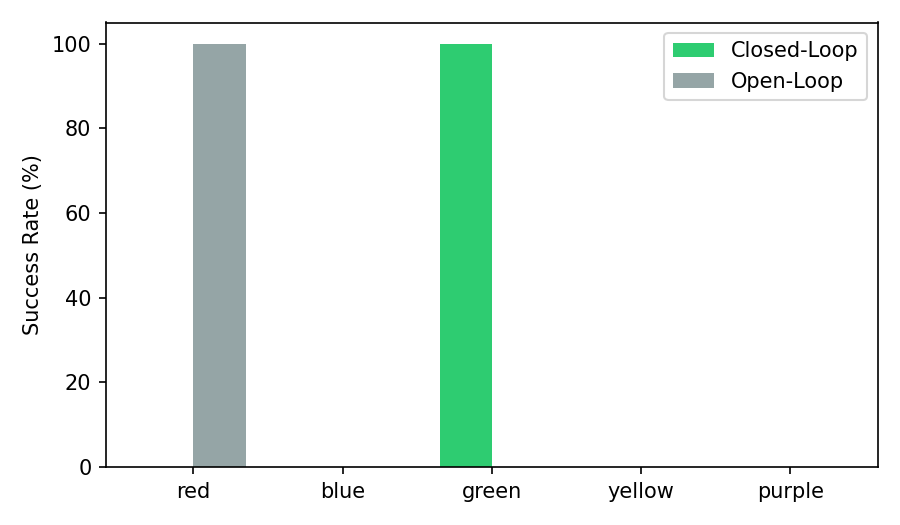

OOD results saved


In [25]:
# Pre-defined OOD conditions: vary cube color
OOD_CONDITIONS = [
    ("red",    [0.85, 0.15, 0.15]),
    ("blue",   [0.15, 0.30, 0.85]),
    ("green",  [0.15, 0.75, 0.20]),
    ("yellow", [0.90, 0.80, 0.10]),
    ("purple", [0.70, 0.15, 0.70]),
]


def apply_ood_condition(env, rgb):
    """Set cube geom to the given RGB color."""
    for i in range(env.sim.model.ngeom):
        name = env.sim.model.geom_names[i]
        if isinstance(name, bytes): name = name.decode()
        if "cube" in name.lower():
            rgba = list(env.sim.model.geom_rgba[i])
            rgba[:3] = list(rgb); rgba[3] = 1.0
            env.sim.model.geom_rgba[i] = rgba
            break
    return env


def evaluate_ood(feedback, n, parser, grounder, video_prefix="", conditions=None):
    if conditions is None:
        conditions = OOD_CONDITIONS[:n]
    ctrl_cls = ClosedLoopController if feedback else OpenLoopController
    results = []
    for trial, (color_name, rgb) in enumerate(conditions):
        cmd = f"pick up the {color_name} cube"
        print(f"\nOOD Trial {trial+1}/{len(conditions)}: color={color_name}")
        env = make_env(cfg); env.reset()
        env = apply_ood_condition(env, rgb)
        cam = VideoCapture(fps=4) if video_prefix else None
        ctrl = ctrl_cls(env, parser, grounder,
                        on_frame=cam.snap if cam else None)
        results.append(ctrl.run(cmd))
        if cam:
            cam.save(f"{video_prefix}_trial{trial+1}.mp4")
            print(f"  Video saved")
        env.close()
    return results


def ood_summary(all_results, conditions):
    sep = "=" * 40
    print(f"\n{sep}\nOOD Summary\n{sep}")
    total_ok = total_n = 0
    for label, results in all_results:
        n, ok = len(results), sum(1 for r in results if r.success)
        total_ok += ok; total_n += n
        print(f"  {label:20s}: {ok}/{n} = {100*ok/n:.1f}%")
        for cond, r in zip(conditions, results):
            print(f"    {cond[0]:10s}: {'OK' if r.success else 'FAIL'} ({r.error or '-'})")
    print(f"\n  {'TOTAL':20s}: {total_ok}/{total_n} = {100*total_ok/total_n:.1f}%\n{sep}")


if torch.cuda.is_available():
    n = min(len(OOD_CONDITIONS), 5)
    conds = OOD_CONDITIONS[:n]
    parser = DSLParser(cfg.llm_model_id, cfg.use_4bit)
    grounder = VisionGrounder(cfg.vision_model_id)
    r_cl = evaluate_ood(True, n, parser, grounder, video_prefix="ood_cl", conditions=conds)
    r_ol = evaluate_ood(False, n, parser, grounder, video_prefix="ood_ol", conditions=conds)
    parser.unload(); grounder.unload()
    ood_summary([("Closed-Loop", r_cl), ("Open-Loop", r_ol)], conds)

    fig, ax = plt.subplots(figsize=(6, 3.5))
    x = range(len(conds)); w = 0.35
    ax.bar([xi - w/2 for xi in x], [100*r.success for r in r_cl], w,
           label="Closed-Loop", color="#2ecc71")
    ax.bar([xi + w/2 for xi in x], [100*r.success for r in r_ol], w,
           label="Open-Loop", color="#95a5a6")
    ax.set_xticks(list(x)); ax.set_xticklabels([c[0] for c in conds])
    ax.set_ylabel("Success Rate (%)"); ax.set_ylim(0, 105); ax.legend()
    plt.tight_layout()
    plt.savefig("ood_results.png", dpi=150); plt.close()
    from IPython.display import Image as DispImage
    display(DispImage("ood_results.png"))
    torch.save({"ood_closed_loop": r_cl, "ood_open_loop": r_ol, "conditions": conds},
               "eval_results_ood.pt")
    print("OOD results saved")
else:
    print("Skip: no GPU")

---
## Usage Notes

| Step | Action |
|---|---|
| 1 | Enable **GPU T4 x2** in Kaggle Accelerator |
| 2 | Run cells **1 → 12** in order |
| 3 | First run downloads Qwen2.5-3B (~6 GB) + Florence-2 (~1.5 GB) — ≈2–3 min |
| 4 | **Cell 9** generates annotated video; **Cell 10** runs batch evaluation |
| 5 | Increase `cfg.n_trials` to 50+ in Cell 4 for publishable results |

### Common Issues

| Symptom | Fix |
|---|---|
| **numpy/numba error** | Rerun Cell 2, then **restart kernel**, run from Cell 3 |
| **EGL error** on render | Rerun Cell 1 then restart kernel |
| **OOM** (CUDA out of memory) | Use `Qwen/Qwen2.5-1.5B-Instruct` or `microsoft/Florence-2-base` |
| **bitsandbytes OOM** | In Cell 5, set `cfg.use_4bit = True` (default) |
| **Controller error** | Robosuite 1.5 uses `load_composite_controller_config("BASIC")` |
| **Results lost** | Download `eval_results*.pt` + `output.mp4` from Kaggle working dir |

### Architecture

```
NL Command --> [LLM] --> DSL JSON
DSL + RGB  --> [Florence-2] --> 2D BBox
BBox + table geometry --> 3D Target  (ray-plane intersection)
3D Target --> [OSC_POSE Controller] --> Robot Actions
                  ^--- periodic visual feedback ---|
```